# <span style="color:red"> QTM 151 - Quiz 5 </span>

### Submit as an **HTML file**
### Quiz is open 1:00pm to 1:55pm

<font size = "4" >
This quiz is open book 

- You can use the lecture notes
- You will get partial credit for attempting the questions
- To get full credit, the code should work as intended
- You should <span style="color:red"> NOT </span> communicate with other students

Print the following message: <br>

"I will abide by Emory's code of conduct"

In [1]:
# Write your answer here

print("I will abide by Emory's code of conduct")

I will abide by Emory's code of conduct


In [37]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

<font size = "5">

1. Replacing strings

<font size = "4">

- Read in the data from "yelp_reviews.csv", assigning the output to a DataFrame.

- This dataset contains a large number of restaurant reviews from yelp.com. The text of each review is stored in the "review" column.

- In the "review" column, do the following:

    - Replace all instances of the word "champaign" with "Champaign" (it is a proper noun, the name of a city in Illinois)
    - Replace all instances of the phrase "Champaign Urbana" with "Champaign-Urbana".

- Make sure the replacements you make are being applied to the original DataFrame.


In [44]:
yelp = pd.read_csv("data_quiz/yelp_reviews.csv")

yelp["review"] = yelp["review"].str.replace("champaign", "Champaign")
yelp["review"] = yelp["review"].str.replace("Champaign Urbana", "Champaign-Urbana")

yelp

,url,rating,date,review
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...
...,...,...,...,...
19890,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,7/17/2021,Had the chocolate cannoli! The filling was ric...
19891,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,10/21/2019,Love apricot croissant! I bought it at 4:00 PM...
19892,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,10/12/2019,Line was about 25 people long. It went fast! T...
19893,https://www.yelp.com/biz/la-pasticceria-las-vegas,5,4/11/2021,Its hard not to order everything when I come h...


<font size = "5">

2. Look for reviews containing a string pattern

<font size = "4">

- Search for all reviews that contain a string describing a range of years, such as "1992-1998" or "2000-2007".

- Create a DataFrame called ``df_year`` that consists of all the rows of the original DataFrame for which you found a range of years in the Yelp review.

- We can characterize a range of years as: 4 digit characters, followed by a dash, followed by 4 digit characters.


In [43]:
yearrange = r"\d{4}-\d{4}" 
df_year = yelp[yelp["review"].str.contains(yearrange, regex=True, na=False)]
df_year

,url,rating,date,review,tokens
12240,https://www.yelp.com/biz/prestis-bakery-cleveland,5,9/7/2008,Lived in Cleveland Heights for 5 years (1987-1...,"[lived, in, cleveland, heights, for, years, pr..."
14737,https://www.yelp.com/biz/jarlings-custard-cup-...,4,8/18/2009,"On a journey to revisit my mom's college town,...","[on, a, journey, to, revisit, my, mom's, colle..."
17759,https://www.yelp.com/biz/masons-creamery-cleve...,5,10/2/2016,Very yummy vegan ice creams. The moment you st...,"[very, yummy, vegan, ice, creams, the, moment,..."


<font size = "5">

3. Find similarly spelled words

<font size = "4">

- Find all occurences of the words "place", "places", "plate", and "plates" in the reviews by using ``.str.findall`` **one time**. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)

In [ ]:
wordsearch = yelp["review"].str.findall("place|places|plate|plates")
display(wordsearch)

wordsearch_len = wordsearch.str.len()
display(wordsearch_len[wordsearch_len > 0])

0             []
1        [place]
2             []
3             []
4        [place]
          ...   
19890         []
19891         []
19892         []
19893         []
19894         []
Name: review, Length: 19895, dtype: object

1        1
4        1
5        1
6        1
7        1
        ..
19871    1
19874    1
19879    1
19884    1
19887    1
Name: review, Length: 7511, dtype: int64

<font size = "5">

4. Find words ending with "y"

<font size = "4">

- Find all words ending with the letter "y" by using ``.str.findall``. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Specifically, you are looking for one or more consecutive alphabetical characters (both upper and lower case) or apostrophe (single quote) characters followed by the letter "y".

- In order to ensure that the word **ends** with "y", add the special character "\\\b" (two backslashes and a "b") immediately after the "y". This is called a word boundary.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)



In [ ]:
y = yelp["review"].str.findall("[a-zA-Z']+y\\b")
y_len = y.str.len()
display(y_len[y_len > 0])

0         4
1         3
2         3
3         4
4        11
         ..
19890     3
19891     6
19892     4
19893     3
19894    10
Name: review, Length: 19053, dtype: int64

<font size = "5">

5. Convert reviews to individual words

<font size = "4">

- Add a new column to the DataFrame with the name "tokens", where each row of the column is a list containing all individual words appearing in the Yelp review for that row.

- For the purposes of this question, we will take a single word to be one or more consecutive occurrences of the letters, A-Z, a-z, and the apostrophe character.

- Then use ``.apply`` to ensure every word in the "tokens" column is lowercase. Make sure you are actually changing the "tokens" column of the DataFrame in this step.

- **Note:** There are no "NaNs" in the "review" column, so it shouldn't be necessary to account for the case where an entry in the "tokens" column isn't actually a list.

In [45]:
yelp["tokens"] = yelp["review"].str.findall("[a-zA-Z']+")

def lower_list(lst):
    out = []
    if not isinstance(lst, list):
        return tuple(out)
    for w in lst:
        out.append(w.lower())
    return tuple(out)

yelp["tokens"] = yelp["tokens"].apply(lower_list)
yelp

,url,rating,date,review,tokens
0,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,1/22/2022,All I can say is they have very good ice cream...,"(all, i, can, say, is, they, have, very, good,..."
1,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,6/26/2022,Nice little local place for ice cream.My favor...,"(nice, little, local, place, for, ice, cream, ..."
2,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,8/7/2021,A delicious treat on a hot day! Staff was very...,"(a, delicious, treat, on, a, hot, day, staff, ..."
3,https://www.yelp.com/biz/sidney-dairy-barn-sidney,4,7/28/2016,This was great service and a fun crew! I got t...,"(this, was, great, service, and, a, fun, crew,..."
4,https://www.yelp.com/biz/sidney-dairy-barn-sidney,5,6/23/2015,This is one of my favorite places to get ice c...,"(this, is, one, of, my, favorite, places, to, ..."
...,...,...,...,...,...
19890,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,7/17/2021,Had the chocolate cannoli! The filling was ric...,"(had, the, chocolate, cannoli, the, filling, w..."
19891,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,10/21/2019,Love apricot croissant! I bought it at 4:00 PM...,"(love, apricot, croissant, i, bought, it, at, ..."
19892,https://www.yelp.com/biz/la-pasticceria-las-vegas,4,10/12/2019,Line was about 25 people long. It went fast! T...,"(line, was, about, people, long, it, went, fas..."
19893,https://www.yelp.com/biz/la-pasticceria-las-vegas,5,4/11/2021,Its hard not to order everything when I come h...,"(its, hard, not, to, order, everything, when, ..."


<font size = "5">

6. Convert reviews to individual words

<font size = "4">

- Unravel the values from "tokens" into a single Pandas Series containing all the words appearing in every review.

- Then, create a new Pandas Series containing the probabilities/proportions of each word. This Pandas Series will have an index column (the tokens/words) and the single "proper" column will be the proportions/probabilities.

- Create a bar plot of the probabilities of the 13 most frequently occuring words in the dataset. Add a label to the y-axis and a title.

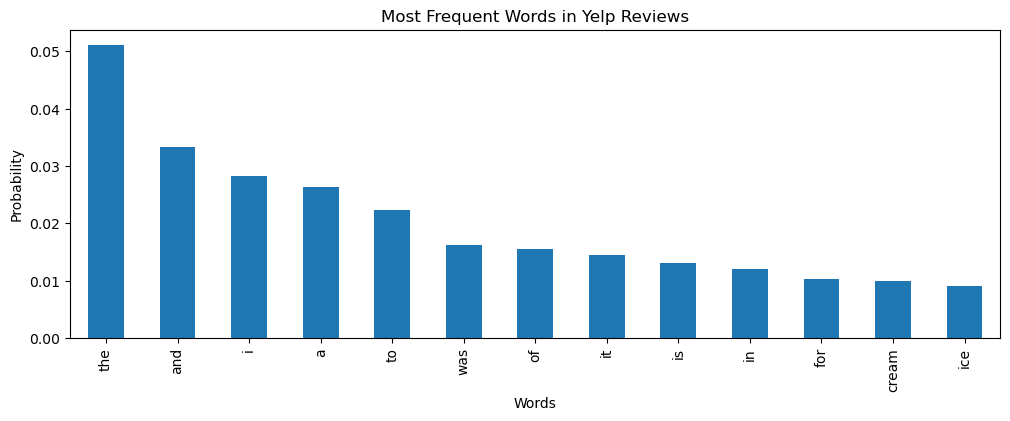

In [46]:
word_frequency = yelp["tokens"].explode()

word_probs = word_frequency.value_counts(normalize = True)
word_probs.head(13).plot(kind='bar', figsize=(12,4))
plt.title("Most Frequent Words in Yelp Reviews")
plt.xlabel("Words")
plt.ylabel("Probability")
plt.show()